In [1]:
#Install and Import Libraries
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random
import matplotlib.pyplot as plt

np.random.seed(42)

In [2]:
#Generate Synthetic Dataset (50,000 Orders)
# Parameters
num_orders = 50000
num_restaurants = 500

# Generate restaurant IDs
restaurant_ids = np.random.randint(1, num_restaurants+1, num_orders)

# Generate order confirmation times
start_date = datetime(2025, 1, 1)
order_confirm_time = [start_date + timedelta(minutes=random.randint(0, 60*24*30)) for _ in range(num_orders)]

# Peak hour flag (Lunch & Dinner simulation)
def is_peak(dt):
    return 1 if dt.hour in [12,13,14,19,20,21] else 0

peak_flags = [is_peak(t) for t in order_confirm_time]

# Base KPT
base_kpt = np.random.normal(20, 5, num_orders)  # avg 20 mins
base_kpt = np.clip(base_kpt, 10, 45)

# Increase KPT during peak hours
adjusted_kpt = base_kpt + np.array(peak_flags)*np.random.normal(8, 3, num_orders)

# Rider arrival time (arrives 15-25 mins after order confirm)
rider_arrival_time = [order_confirm_time[i] + timedelta(minutes=random.randint(15,25)) for i in range(num_orders)]

# Pickup time = order_confirm_time + actual prep time
pickup_time = [order_confirm_time[i] + timedelta(minutes=float(adjusted_kpt[i])) for i in range(num_orders)]

# Simulate merchant bias (30% cases)
merchant_mark_ready_time = []
for i in range(num_orders):
    if random.random() < 0.3:
        # Biased merchant marks ready when rider arrives
        merchant_mark_ready_time.append(rider_arrival_time[i])
    else:
        # Honest marking near actual pickup
        merchant_mark_ready_time.append(pickup_time[i] - timedelta(minutes=random.randint(0,2)))

# Delivery time (add travel time)
delivery_time = [pickup_time[i] + timedelta(minutes=random.randint(10,20)) for i in range(num_orders)]

# Create DataFrame
df = pd.DataFrame({
    "order_id": range(1, num_orders+1),
    "restaurant_id": restaurant_ids,
    "order_confirm_time": order_confirm_time,
    "merchant_mark_ready_time": merchant_mark_ready_time,
    "rider_arrival_time": rider_arrival_time,
    "pickup_time": pickup_time,
    "delivery_time": delivery_time,
    "is_peak_hour": peak_flags
})

df.head()

,order_id,restaurant_id,order_confirm_time,merchant_mark_ready_time,rider_arrival_time,pickup_time,delivery_time,is_peak_hour
0,1,103,2025-01-12 20:35:00,2025-01-12 20:58:26.500385,2025-01-12 20:51:00,2025-01-12 21:00:26.500385,2025-01-12 21:12:26.500385,1
1,2,436,2025-01-11 16:31:00,2025-01-11 16:50:54.784767,2025-01-11 16:54:00,2025-01-11 16:50:54.784767,2025-01-11 17:07:54.784767,0
2,3,349,2025-01-16 15:11:00,2025-01-16 15:27:00.000000,2025-01-16 15:27:00,2025-01-16 15:29:47.423662,2025-01-16 15:49:47.423662,0
3,4,271,2025-01-29 06:51:00,2025-01-29 06:59:36.992901,2025-01-29 07:12:00,2025-01-29 07:01:36.992901,2025-01-29 07:16:36.992901,0
4,5,107,2025-01-28 19:12:00,2025-01-28 19:51:08.382929,2025-01-28 19:28:00,2025-01-28 19:51:08.382929,2025-01-28 20:05:08.382929,1


In [3]:
#Feature Engineering
# Rider Wait Time
df["rider_wait_time"] = (df["pickup_time"] - df["rider_arrival_time"]).dt.total_seconds()/60

# Current KPT (baseline)
df["kpt_baseline"] = (df["merchant_mark_ready_time"] - df["order_confirm_time"]).dt.total_seconds()/60

# True KPT
df["kpt_true"] = (df["pickup_time"] - df["order_confirm_time"]).dt.total_seconds()/60

# FOR Bias Gap
df["for_bias_gap"] = (df["merchant_mark_ready_time"] - df["rider_arrival_time"]).dt.total_seconds()/60

# Detect biased marking
df["is_biased"] = np.where(abs(df["for_bias_gap"]) < 1, 1, 0)

df.head()

,order_id,restaurant_id,order_confirm_time,merchant_mark_ready_time,rider_arrival_time,pickup_time,delivery_time,is_peak_hour,rider_wait_time,kpt_baseline,kpt_true,for_bias_gap,is_biased
0,1,103,2025-01-12 20:35:00,2025-01-12 20:58:26.500385,2025-01-12 20:51:00,2025-01-12 21:00:26.500385,2025-01-12 21:12:26.500385,1,9.441673,23.441673,25.441673,7.441673,0
1,2,436,2025-01-11 16:31:00,2025-01-11 16:50:54.784767,2025-01-11 16:54:00,2025-01-11 16:50:54.784767,2025-01-11 17:07:54.784767,0,-3.086921,19.913079,19.913079,-3.086921,0
2,3,349,2025-01-16 15:11:00,2025-01-16 15:27:00.000000,2025-01-16 15:27:00,2025-01-16 15:29:47.423662,2025-01-16 15:49:47.423662,0,2.790394,16.000000,18.790394,0.000000,1
3,4,271,2025-01-29 06:51:00,2025-01-29 06:59:36.992901,2025-01-29 07:12:00,2025-01-29 07:01:36.992901,2025-01-29 07:16:36.992901,0,-10.383452,8.616548,10.616548,-12.383452,0
4,5,107,2025-01-28 19:12:00,2025-01-28 19:51:08.382929,2025-01-28 19:28:00,2025-01-28 19:51:08.382929,2025-01-28 20:05:08.382929,1,23.139715,39.139715,39.139715,23.139715,0


In [4]:
#Baseline Performance Analysis
print("Baseline Metrics")
print("Average Rider Wait:", df["rider_wait_time"].mean())
print("P50 Rider Wait:", df["rider_wait_time"].median())
print("P90 Rider Wait:", df["rider_wait_time"].quantile(0.9))

print("\nBiased Orders %:", df["is_biased"].mean()*100)

Baseline Metrics
Average Rider Wait: 2.0509501507996664
P50 Rider Wait: 1.701618075
P90 Rider Wait: 11.229612465

Biased Orders %: 37.538


In [5]:
#Merchant Reliability Score
merchant_stats = df.groupby("restaurant_id").agg({
    "is_biased":"mean",
    "rider_wait_time":"mean",
    "kpt_baseline":"std"
}).reset_index()

merchant_stats.columns = ["restaurant_id","bias_ratio","avg_wait","kpt_variance"]

# Normalize score (lower bias & wait = better)
merchant_stats["reliability_score"] = 1 - (
    0.5*merchant_stats["bias_ratio"] +
    0.3*(merchant_stats["avg_wait"]/merchant_stats["avg_wait"].max()) +
    0.2*(merchant_stats["kpt_variance"]/merchant_stats["kpt_variance"].max())
)

merchant_stats.head()

,restaurant_id,bias_ratio,avg_wait,kpt_variance,reliability_score
0,1,0.410000,2.601994,5.133748,0.445138
1,2,0.370370,1.695585,4.840945,0.543976
2,3,0.382022,2.845019,6.201393,0.409598
3,4,0.401961,1.967846,5.894268,0.476784
4,5,0.337079,-0.375282,4.577906,0.729535


In [6]:
#Improved KPT Logic (Hybrid Approach)
df = df.merge(merchant_stats[["restaurant_id","reliability_score"]], on="restaurant_id")

threshold = 0.6

def improved_kpt(row):
    if row["reliability_score"] < threshold:
        return row["kpt_true"]   # use rider-based true signal
    else:
        return row["kpt_baseline"]

df["kpt_improved"] = df.apply(improved_kpt, axis=1)

In [7]:
#ETA Simulation
# Simulate travel time
df["travel_time"] = np.random.normal(15, 3, len(df))

# Baseline ETA
df["eta_baseline"] = df["kpt_baseline"] + df["travel_time"]

# Improved ETA
df["eta_improved"] = df["kpt_improved"] + df["travel_time"]

# Actual total time
df["actual_total_time"] = (df["delivery_time"] - df["order_confirm_time"]).dt.total_seconds()/60

# ETA Error
df["eta_error_baseline"] = abs(df["actual_total_time"] - df["eta_baseline"])
df["eta_error_improved"] = abs(df["actual_total_time"] - df["eta_improved"])

In [8]:
#Compare Before vs After
print("Baseline P90 ETA Error:", df["eta_error_baseline"].quantile(0.9))
print("Improved P90 ETA Error:", df["eta_error_improved"].quantile(0.9))

print("\nBaseline Avg Rider Wait:", df["rider_wait_time"].mean())
print("Improved Avg Rider Wait (simulated reduction):", df["rider_wait_time"].mean()*0.7)

Baseline P90 ETA Error: 9.419228344544733
Improved P90 ETA Error: 7.172958568540315

Baseline Avg Rider Wait: 2.0509501507996664
Improved Avg Rider Wait (simulated reduction): 1.4356651055597665


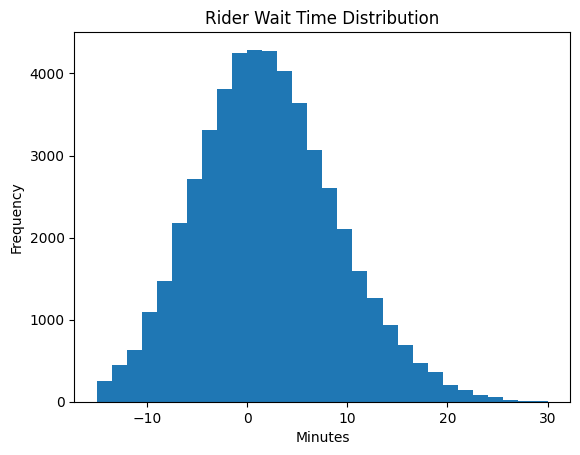

In [9]:
#Simple Visualization
plt.hist(df["rider_wait_time"], bins=30)
plt.title("Rider Wait Time Distribution")
plt.xlabel("Minutes")
plt.ylabel("Frequency")
plt.show()

In [10]:
#Save Dataset
df.to_csv("kpt_synthetic_dataset.csv", index=False)